# Instructions 
- https://mesa.readthedocs.io/stable/

In [1]:
!pip install -U mesa

  Using cached mesa-3.5.1-py3-none-any.whl.metadata (11 kB)
  Using cached pythran-0.18.1-py3-none-any.whl.metadata (7.9 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached ply-3.11-py2.py3-none-any.whl.metadata (844 bytes)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached beniget-0.4.2.post1-py3-none-any.whl.metadata (820 bytes)
Using cached mesa-3.5.1-py3-none-any.whl (275 kB)
Using cached pythran-0.18.1-py3-none-any.whl (4.4 MB)
Using cached beniget-0.4.2.post1-py3-none-any.whl (17 kB)
Using cached gast-0.6.0-py3-none-any.whl (21 kB)
Using cached ply-3.11-py2.py3-none-any.whl (49 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install -U "mesa[rec]"

  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached solara-1.57.3-py3-none-any.whl.metadata (10 kB)
  Using cached starlette-0.52.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached solara_server-1.57.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached solara_ui-1.57.3-py3-none-any.whl.metadata (7.3 kB)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl

# Overview 
- https://mesa.readthedocs.io/stable/getting_started.html
- https://mesa.readthedocs.io/stable/overview.html

## Basic model

In [ ]:
import mesa

class MyAgent(mesa.Agent):
    def __init__(self, model, age):
        super().__init__(model)
        self.age = age

    def step(self):
        self.age += 1
        print(f"Agent {self.unique_id} now is {self.age} years old")
        # Whatever else the agent does when activated

class MyModel(mesa.Model):
    def __init__(self, n_agents):
        super().__init__()
        self.grid = mesa.discrete_space.OrthogonalMooreGrid((10, 10), torus=True)
        initial_ages = self.rng.integers(0, 80, size=n_agents)
        agents = MyAgent.create_agents(self, n_agents, initial_ages)
        for agent in agents:
            agent.cell = self.grid.all_cells.select_random_cell()

    def step(self):
        self.agents.shuffle_do("step")
        #self.agents.do("step")

In [7]:
model = MyModel(n_agents=5)
#model.run_for(1)
model.run_for(3)

Agent 1 now is 26 years old
Agent 2 now is 47 years old
Agent 3 now is 14 years old
Agent 4 now is 76 years old
Agent 5 now is 49 years old
Agent 1 now is 27 years old
Agent 2 now is 48 years old
Agent 3 now is 15 years old
Agent 4 now is 77 years old
Agent 5 now is 50 years old
Agent 1 now is 28 years old
Agent 2 now is 49 years old
Agent 3 now is 16 years old
Agent 4 now is 78 years old
Agent 5 now is 51 years old


## Model with collectors

In [13]:
import mesa
import numpy as np


class MyAgent(mesa.Agent):
    def __init__(self, model, age):
        super().__init__(model)
        self.age = age

    def step(self):
        self.age += 1
        print(f"Agent {self.unique_id} now is {self.age} years old")
        # Whatever else the agent does when activated

class MyModel(mesa.Model):
    def __init__(self, n_agents):
        super().__init__()
        self.grid = mesa.discrete_space.OrthogonalMooreGrid((10, 10), torus=True)
        initial_ages = self.rng.integers(0, 80, size=n_agents)
        agents = MyAgent.create_agents(self, n_agents, initial_ages)
        for agent in agents:
            agent.cell = self.grid.all_cells.select_random_cell()

        self.datacollector = mesa.DataCollector(
            model_reporters={"mean_age": lambda m: m.agents.agg("age", np.mean)},
            agent_reporters={"age": "age"}
        )

    def step(self):
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

        #self.agents.do("step")

In [14]:
model = MyModel(5)
model.run_for(10)
model_df = model.datacollector.get_model_vars_dataframe()
agent_df = model.datacollector.get_agent_vars_dataframe()

Agent 4 now is 46 years old
Agent 5 now is 20 years old
Agent 1 now is 4 years old
Agent 2 now is 31 years old
Agent 3 now is 45 years old
Agent 2 now is 32 years old
Agent 5 now is 21 years old
Agent 4 now is 47 years old
Agent 3 now is 46 years old
Agent 1 now is 5 years old
Agent 1 now is 6 years old
Agent 4 now is 48 years old
Agent 5 now is 22 years old
Agent 2 now is 33 years old
Agent 3 now is 47 years old
Agent 1 now is 7 years old
Agent 5 now is 23 years old
Agent 3 now is 48 years old
Agent 2 now is 34 years old
Agent 4 now is 49 years old
Agent 2 now is 35 years old
Agent 3 now is 49 years old
Agent 5 now is 24 years old
Agent 1 now is 8 years old
Agent 4 now is 50 years old
Agent 5 now is 25 years old
Agent 2 now is 36 years old
Agent 1 now is 9 years old
Agent 3 now is 50 years old
Agent 4 now is 51 years old
Agent 2 now is 37 years old
Agent 3 now is 51 years old
Agent 5 now is 26 years old
Agent 4 now is 52 years old
Agent 1 now is 10 years old
Agent 4 now is 53 years ol

/Users/andreavandin/Documents/GitHub/ComputationalEconomicsVandin20252026/jupyter/jupyterNotebooks/.venv/lib/python3.14/site-packages/mesa/discrete_space/grid.py:104: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)


In [15]:
model_df

,mean_age
0,29.2
1,30.2
2,31.2
3,32.2
4,33.2
5,34.2
6,35.2
7,36.2
8,37.2
9,38.2


In [16]:
agent_df

age
Step AgentID     
1.0  1          4
     2         31
     3         45
     4         46
     5         20
2.0  1          5
     2         32
     3         46
     4         47
     5         21
3.0  1          6
     2         33
     3         47
     4         48
     5         22
4.0  1          7
     2         34
     3         48
     4         49
     5         23
5.0  1          8
     2         35
     3         49
     4         50
     5         24
6.0  1          9
     2         36
     3         50
     4         51
     5         25
7.0  1         10
     2         37
     3         51
     4         52
     5         26
8.0  1         11
     2         38
     3         52
     4         53
     5         27
9.0  1         12
     2         39
     3         53
     4         54
     5         28
10.0 1         13
     2         40
     3         54
     4         55
     5         29

# Creating your first agent-based model with Mesa
- https://mesa.readthedocs.io/stable/tutorials/0_first_model.html
- The Botlzmann wealth model

In [1]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [19]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def say_hi(self):
        # The agent's step will go here.
        # For demonstration purposes we will print the agent's unique_id
        print(f"Hi, I am an agent, you can call me {self.unique_id!s}.")

    def say_wealth(self):
        print("Hi, I am an agent and I have ",self.wealth,"!")
        print()

    def exchange(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth -= 1

In [20]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n
        # Create agents
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        """Advance the model by one step."""
        # This function psuedo-randomly reorders the list of agent objects and
        # then iterates through calling the function passed in as the parameter
        #self.agents.shuffle_do("say_hi")
        #self.agents.shuffle_do("say_wealth")
        self.agents.shuffle_do("exchange")




In [24]:
starter_model = MoneyModel(10)
starter_model.step()

In [25]:
starter_model.step()

In [26]:
starter_model.run_for(3)

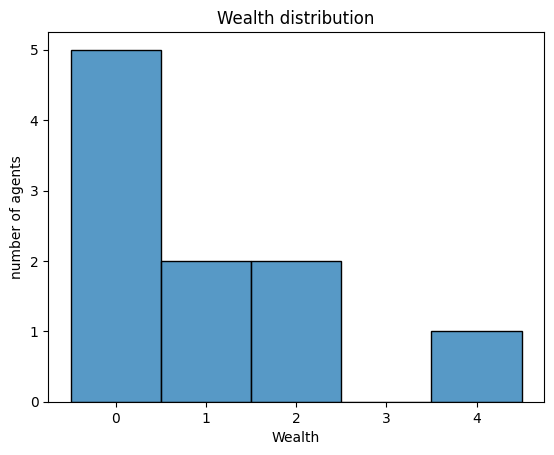

In [28]:
agent_wealth = [a.wealth for a in starter_model.agents]
# Create a histogram with seaborn
g = sns.histplot(agent_wealth, discrete=True)
g.set(
    title="Wealth distribution", xlabel="Wealth", ylabel="number of agents"
);  # The semicolon is just to avoid printing the object representation

# Mesa frames
- https://github.com/mesa/mesa-frames

# Schelling
- Recap
- Agentic Schelling